(('call_subgraph',), 'updates', {'subgraph_strip_node': {'stripped_text': 'LangGraph 真有意思'}})

(('call_subgraph',), 'updates', {'subgraph_punctuate_node': {'punctuated_text': 'LangGraph 真有意思。'}})

((), 'updates', {'call_subgraph': {'cleaned_text': 'LangGraph 真有意思。'}})

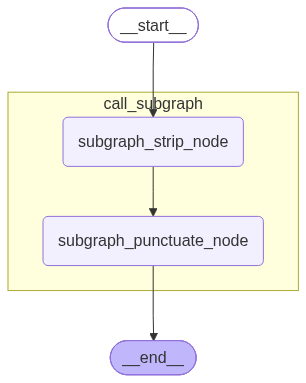

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	__end__([<p>__end__</p>]):::last
	__start__ --> call_subgraph\3asubgraph_strip_node;
	call_subgraph\3asubgraph_punctuate_node --> __end__;
	subgraph call_subgraph
	call_subgraph\3asubgraph_strip_node(subgraph_strip_node)
	call_subgraph\3asubgraph_punctuate_node(subgraph_punctuate_node)
	call_subgraph\3asubgraph_strip_node --> call_subgraph\3asubgraph_punctuate_node;
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from rich import print as rprint

# 构建子图
class SubgraphState(TypedDict):
    raw_text: str # 未清洗文本
    stripped_text: str # 去除收尾空格的文本
    punctuated_text: str # 句尾添加句号的文本

def subgraph_strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()

    return {
        "stripped_text": stripped_text
    }

def subgraph_punctuate_node(state: SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + "。"

    return {
        "punctuated_text": punctuated_text
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuate_node", subgraph_punctuate_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuate_node")
builder.add_edge("subgraph_punctuate_node", END)

subgraph = builder.compile(checkpointer=True)

# 构建父图
class ParentState(TypedDict):
    input_text: str # 输入的未清洗的文本
    cleaned_text: str # 清洗后的文本

def call_subgraph(state: ParentState) -> ParentState:
    input_text = state["input_text"]

    res = subgraph.invoke({"raw_text": input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text": cleaned_text
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)

builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

parent_graph = builder.compile()

input_text = "   LangGraph 真有意思        "
for chunk in parent_graph.stream(
    {"input_text": input_text},
    # 开启子图的数据流式输出 => 添加子图的数据到总的数据中
    subgraphs=True,
    stream_mode=["updates"]
):
    rprint(chunk)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)
raw_mermaid = parent_graph.get_graph(xray=True).draw_mermaid()
print(raw_mermaid)
